In [1]:
# For simulation
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeKolkataV2, FakeCairoV2

from qiskit import QuantumCircuit, transpile

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from qiskit.quantum_info import random_unitary
from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate

from dicke_states import dicke_state

backend = AerSimulator()#.from_backend(FakeKolkata())

/Users/vincent.russo/Projects/research/wigners_friend/notebooks/dicke_states.py:252: SyntaxWarning: invalid escape sequence '\o'
  str_operator = r"$1^{\otimes " + f'{n_first}' + "} \otimes$ SCS$_{" + f"{l},{k}" + "} \otimes 1^{\otimes " + f"{n_last}" + "}$"
/Users/vincent.russo/Projects/research/wigners_friend/notebooks/dicke_states.py:252: SyntaxWarning: invalid escape sequence '\o'
  str_operator = r"$1^{\otimes " + f'{n_first}' + "} \otimes$ SCS$_{" + f"{l},{k}" + "} \otimes 1^{\otimes " + f"{n_last}" + "}$"
/Users/vincent.russo/Projects/research/wigners_friend/notebooks/dicke_states.py:302: SyntaxWarning: invalid escape sequence '\o'
  str_operator = r"SCS$_{" + f"{l},{l-1}" + "} \otimes 1^{\otimes " + f"{n_last}" + "}$"


## EWFS with controlled random unitaries

In [2]:
import numpy as np
import itertools
import os
import pickle
import random
from enum import Enum
import matplotlib.pyplot as plt

import qiskit

from qiskit_aer.noise import NoiseModel, depolarizing_error, pauli_error, ReadoutError
from qiskit.providers import Backend
from qiskit.providers import fake_provider
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

DATA_PATH = os.path.join("..", "data")

In [3]:
# Settings for extended Wigner's friend scenario.
class Setting(Enum):
    PEEK = 1
    REVERSE_1 = 2
    REVERSE_2 = 3

# Observers for scenario are Alice and Bob.
class Observer(Enum):
    ALICE = 0
    BOB = 1

# Experiment settings (peek, reverse_1, and reverse_2).
PEEK = Setting.PEEK.value
REVERSE_1 = Setting.REVERSE_1.value
REVERSE_2 = Setting.REVERSE_2.value
SETTINGS = [PEEK, REVERSE_1, REVERSE_2]

# "Super"-observers (Alice and Bob).
ALICE = Observer.ALICE.value
BOB = Observer.BOB.value
OBSERVERS = [ALICE, BOB]

# Angles and beta term used for Alice and Bob measurement operators from arXiv:1907.05607.
# Note that despite the fact that degrees are used, we need to convert this to radians.
# ANGLES = {PEEK: np.deg2rad(168), REVERSE_1: np.deg2rad(0), REVERSE_2: np.deg2rad(118)}
# BETA = np.deg2rad(175)
ANGLES = {PEEK: np.deg2rad(40), REVERSE_1: np.deg2rad(230), REVERSE_2: np.deg2rad(310)}
BETA = np.deg2rad(220)

In [4]:
def prepare_bipartite_system(qc: QuantumCircuit):
    """Generates the state: 1/sqrt(2) * (|01> - |10>)"""
    qc.x(ALICE)
    qc.x(BOB)
    qc.h(ALICE)
    qc.cx(ALICE, BOB)

In [5]:
def ctrl_random_unitary(qc: QuantumCircuit, random_unitary, observer: Observer, friend_register: list[int], reverse: bool):
    """Apply controlled Random Unitary."""
    if reverse:
        inv_random_u = random_unitary.inverse()
        ctrl_inv_random_u = inv_random_u.control(1)
        qc.append(ctrl_inv_random_u, [observer] + friend_register)
    else:
        ctrl_random_u = random_unitary.control(1)
        qc.append(ctrl_random_u, [observer] + friend_register)

In [6]:
def ewfs_rotation(qc: QuantumCircuit, qubit: int, angle: float):
    qc.rz(-angle, qubit)
    qc.h(qubit)
    
def apply_setting(qc: QuantumCircuit, 
                  random_unitary,
                  observer: Observer, 
                  setting: Setting, 
                  angle: float, 
                  observer_creg: list[int] | int, 
                  friend_qubits: list[int]):
    """Apply either the PEEK or REVERSE_1/REVERSE_2 settings."""    
    if setting is PEEK:
        # Ask friend for the outcome.
        qc.measure(friend_qubits, observer_creg)

    elif setting in [REVERSE_1, REVERSE_2]:
        ctrl_random_unitary(qc, random_unitary, observer, friend_qubits, reverse=True)

        # For either REVERSE_1 or REVERSE_2, apply the appropriate angle rotations.
        # Note that in this case, the rotation should occur on the observer's qubit.
        if observer is ALICE:
            qc.h(ALICE)
            qc.rz(ANGLES[1], ALICE)        

        if observer is BOB:
            qc.h(BOB)        
            qc.rz((BETA - ANGLES[1]), BOB)        
        ewfs_rotation(qc, observer, angle)            
        qc.measure(observer, observer_creg)
        
def ewfs(alice_setting: Setting, 
        bob_setting: Setting, 
        angles: list[float], 
        beta: float,
        charlie_size: int,
        debbie_size: int,
        random_unitary) -> QuantumCircuit:
    """Generate the circuit for extended Wigner's friend scenario."""    
    # Define quantum registers
    alice_size, bob_size = 1, 1
    sys_size = alice_size + bob_size
    meas_size = 2

    alice, bob, charlie, debbie = [
        QuantumRegister(size, name=name) 
        for size, name in zip([alice_size, bob_size, charlie_size, debbie_size], 
                              ["Alice", "Bob", "Charlie", "Debbie"])
    ]    
    if (alice_setting == PEEK and bob_setting != PEEK):
        measurement = ClassicalRegister(charlie_size + 1, name="Measurement")
        alice_creg = list(range(charlie_size))
        bob_creg = charlie_size
    else:
        measurement = ClassicalRegister(meas_size, name="Measurement")
        alice_creg = 0
        bob_creg = 1
        
    # Create the Quantum Circuit with the defined registers
    qc = QuantumCircuit(alice, bob, charlie, debbie, measurement)

    charlie_qubits = range(sys_size, (sys_size + charlie_size))
    debbie_qubits = range(sys_size + charlie_size, sys_size + (charlie_size + debbie_size))
    # Prepare the bipartite quantum system
    prepare_bipartite_system(qc)
    
    # Rotations for measurement.
    ewfs_rotation(qc, ALICE, angles[1])
    ewfs_rotation(qc, BOB, beta - angles[1])

    # Apply the CNOT ladder for Alice-Charlie and Bob-Debbie
    ctrl_random_unitary(qc, random_unitary['charlie'], ALICE, list(charlie_qubits), reverse=False)
    ctrl_random_unitary(qc, random_unitary['debbie'], BOB, list(debbie_qubits), reverse=False)

    # Apply the settings for Alice/Charlie and Bob/Debbie
    apply_setting(qc, random_unitary['charlie'], ALICE, alice_setting, angles[alice_setting], alice_creg, list(charlie_qubits))
    apply_setting(qc, random_unitary['debbie'], BOB, bob_setting, (beta - angles[bob_setting]), bob_creg, list(debbie_qubits))

    return qc

In [7]:
def decode_results(results: dict[str, float], charlie_size: int, debbie_size: int) -> dict[str, float]:
    """Take majority vote of measurement bit-strings."""
    decoded_results = {}

    # For each setting, there is a dictionary of measurement results.
    for setting in results:
        if setting == (PEEK, REVERSE_1) or setting == (PEEK, REVERSE_2):
            # Debbie's size is 1 because no PEEK setting
            debbie_size = 1
            
            setting_results = {}
            # Decode the keys for each measurement result of the setting.
            for k, v in results[setting].items():
                alice_friend, bob_friend = k[:charlie_size], k[-debbie_size:]

                alice_zero_count, bob_zero_count = alice_friend.count("0"), bob_friend.count("0")
   
                alice_decoding = "0" if alice_zero_count >= 0.66*charlie_size else "1"
                # alice_decoding = "0" if alice_zero_count == charlie_size else "1"
                bob_decoding = "0" if bob_zero_count == 1 else "1"

                if alice_decoding + bob_decoding in setting_results.keys():
                    setting_results[alice_decoding + bob_decoding] += v
                else:
                    setting_results[alice_decoding + bob_decoding] = v
            decoded_results[setting] = setting_results
        else:
            decoded_results[setting] = results[setting]
            
    return decoded_results

def double_expect(settings: list[Setting], results: dict) -> float:
    """Expectation value of product of two operators."""
    probs = results[settings]
    # <AB> = P(00) - P(01) - P(10) + P(11)
    return (
        probs.get("00", 0) 
        - probs.get("01", 0) 
        - probs.get("10", 0) 
        + probs.get("11", 0)
    )    

def compute_inequalities(results, verbose=False):
    A1B2 = double_expect((PEEK, REVERSE_1), results)
    A1B3 = double_expect((PEEK, REVERSE_2), results)

    A3B2 = double_expect((REVERSE_2, REVERSE_1), results)
    A3B3 = double_expect((REVERSE_2, REVERSE_2), results)
    
    # Eq. (18) from [1].
    semi_brukner = -A1B2 + A1B3 - A3B2 - A3B3 - 2
    
    if verbose:
        print(f"{semi_brukner=} -- is violated: {semi_brukner > 0}")
        
    return {"semi_brukner": semi_brukner}

In [8]:
def generate_all_experiments(
    backend: Backend,
    shots: float,
    angles: list[float],
    beta: float,
    charlie_size: int,
    debbie_size: int,
    random_unitary: UnitaryGate
) -> dict[tuple[Observer, Observer], list[float]]:
    """Generate probabilitites for all combinations of experimental settings."""
    all_experiment_combos = [[PEEK, REVERSE_1], [PEEK, REVERSE_2], [REVERSE_2, REVERSE_1], [REVERSE_2, REVERSE_2]]
    
    results = {}
    for alice, bob in all_experiment_combos:
        ewfs_circuit = ewfs(alice, bob, angles, beta, charlie_size, debbie_size, random_unitary)

        ewfs_circuit = transpile(ewfs_circuit, backend=backend, optimization_level=0)

        result = backend.run(ewfs_circuit, shots=shots).result()

        counts = result.get_counts()
        
        # Convert counts to probabilities.
        probabilities = {key[::-1]: value / shots for key, value in counts.items()}

        results[(alice, bob)] = probabilities
    return results

In [9]:
def run_experiment(
    backend: Backend,
    friend_sizes: list[int],
    random_unitaries: list[UnitaryGate],
    shots: float,
    num_trials: int = 1,
    verbose: bool = False,
    save: bool = False,
) -> dict:
    all_results = {
        fs: {inequality: [] for inequality in ["semi_brukner"]}
        for fs in friend_sizes
    }

    for i, friend_size in enumerate(friend_sizes):
        random_unitary = random_unitaries[i]
        # print(f"{friend_size=}")
        for _ in range(num_trials):
            results = generate_all_experiments(
                backend=backend,
                shots=shots,
                angles=ANGLES,
                beta=BETA,
                charlie_size=friend_size,
                debbie_size=1,
                random_unitary=random_unitary
            )
            violations = compute_inequalities(decode_results(results, charlie_size=friend_size, debbie_size=1), verbose=verbose)
            for key in violations:
                all_results[friend_size][key].append(violations[key])
    if save:
        pass
        # save_data(results=results, backend=backend, friend_sizes=friend_sizes, num_trials=num_trials, shots=shots)
    return all_results

In [10]:
def depolarizing_noise_model(error: float = 0.01) -> NoiseModel:
    """Defines an depolarizing noise model with one-qubit.
    
    Args:
        error: One-qubit gate error rate (default 1%).
    Returns:
        Depolarizing noise model.
    """
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error, 1), ["u1", "u2", "u3"])    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error, 2), "cx")
    return noise_model    

def depolarizing_readout_noise_model(error: float = 0.01, p0givein1: float = 0.01, p1given0: float = 0.01) -> NoiseModel:
    """Defines an depolarizing noise model with one-qubit.
    
    Args:
        error: One-qubit gate error rate (default 1%).
    Returns:
        Depolarizing noise model.
    """
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error, 1), ["u1", "u2", "u3"])    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error, 2), "cx")
    noise_model.add_all_qubit_readout_error(ReadoutError([[1-p1given0, p1given0],[p0givein1, 1-p0givein1]]))
    return noise_model    

In [11]:
# Parameters for all plots
min_friend = 2
friend_sizes = list(range(min_friend,6))

np.random.seed(42)

num_mc = 80
res = np.zeros((num_mc, len(friend_sizes)))
for n in range(num_mc):
    single_qubit_random = UnitaryGate(random_unitary(2))
    random_unitaries = [{'charlie': UnitaryGate(random_unitary(2**size)), 'debbie': single_qubit_random} for size in friend_sizes]
    num_trials = 1
    shots = 10_000
    # backend = AerSimulator(noise_model=None)#.from_backend(FakeKolkata())

    noise_model = None#depolarizing_noise_model(error=0.0005)
    backend = AerSimulator(noise_model=noise_model)
    simulator_results = run_experiment(
        backend=backend,
        friend_sizes=friend_sizes,
        random_unitaries=random_unitaries,
        num_trials=num_trials,
        shots=shots,    
        verbose=False,
        save=True,
    )

    for key in simulator_results.keys():
        res[n][key-min_friend] = simulator_results[key]['semi_brukner'][0]

with open('random_unitary_res.pkl', "wb") as handle:    
    pickle.dump(res, handle, protocol=pickle.HIGHEST_PROTOCOL)


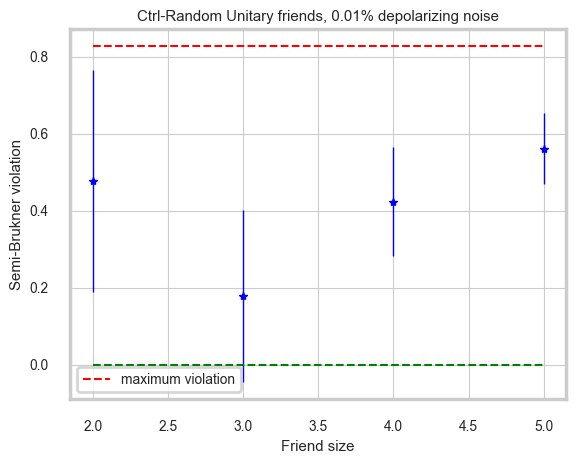

In [12]:
min_friend = 2
friend_sizes = list(range(min_friend,6))

with open(f'random_unitary_res.pkl', 'rb') as handle:
    res = pickle.load(handle)

import seaborn as sns
sns.set_style("whitegrid")

sns.despine(left=True, bottom=True)
sns.set_context("poster", font_scale = .45, rc={"grid.linewidth": 0.8})


plt.errorbar(friend_sizes, np.mean(res, axis=0), np.std(res, axis=0), fmt = '*b', ms=6, elinewidth=1)
plt.plot(friend_sizes, [0.0]*len(friend_sizes), '--g', linewidth=1.5)
plt.plot(friend_sizes, [0.828]*len(friend_sizes), '--r', label='maximum violation', linewidth=1.5)

plt.title('Ctrl-Random Unitary friends, 0.01% depolarizing noise')
plt.ylabel('Semi-Brukner violation')
plt.xlabel('Friend size')
plt.legend()

plt.show()

In [13]:
min_friend = 1
friend_sizes = list(range(min_friend, 8))

random_unitaries = [{'charlie': dicke_state(size, int(np.ceil(size/2))), 'debbie': dicke_state(1,1)} for size in friend_sizes]
num_trials = 5
shots = 10_000
# backend = AerSimulator(noise_model=None)#.from_backend(FakeKolkata())

# Ideal simulator data
noise_model = None #depolarizing_noise_model(error=0.0005)
backend = AerSimulator(noise_model=noise_model)
simulator_results = run_experiment(
    backend=backend,
    friend_sizes=friend_sizes,
    random_unitaries=random_unitaries,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
)

with open('dicke_states_res.pkl', "wb") as handle:    
    pickle.dump(simulator_results, handle, protocol=pickle.HIGHEST_PROTOCOL)

semi_brukner=0.8361999999999998 -- is violated: True
semi_brukner=0.7973999999999997 -- is violated: True
semi_brukner=0.8170000000000002 -- is violated: True
semi_brukner=0.8281999999999998 -- is violated: True
semi_brukner=0.8204000000000002 -- is violated: True
semi_brukner=0.7974000000000001 -- is violated: True
semi_brukner=0.8411999999999997 -- is violated: True
semi_brukner=0.8071999999999999 -- is violated: True
semi_brukner=0.7968000000000002 -- is violated: True
semi_brukner=0.8224 -- is violated: True
semi_brukner=0.8155999999999999 -- is violated: True
semi_brukner=0.8378000000000001 -- is violated: True
semi_brukner=0.8180000000000001 -- is violated: True
semi_brukner=0.8329999999999997 -- is violated: True
semi_brukner=0.8191999999999999 -- is violated: True
semi_brukner=0.7843999999999998 -- is violated: True
semi_brukner=0.7789999999999999 -- is violated: True
semi_brukner=0.8193999999999999 -- is violated: True
semi_brukner=0.8015999999999996 -- is violated: True
semi_

In [14]:
def total_gates(circuit, backend):
    basis_gates=['u1', 'u2', 'u3', 'cx']

    ansatz_transpiled = transpile(circuit, backend, basis_gates=['u1', 'u2', 'u3', 'cx'], optimization_level=2)
    gates = ansatz_transpiled.count_ops()

    total_gates = 0
    for gate in basis_gates:
        total_gates += gates.get(gate, 0)
    return total_gates


def cnot_ladder(qc: QuantumCircuit, size: int):
    """CNOT ladder circuit (GHZ without Hadamard)."""
    qc.x(0)
    for i in range(size-1):
        qc.cx(i, i + 1)

In [15]:
'''Run this cell to get gate data'''

from dicke_states import dicke_state
import numpy as np
dicke_states_gates = []
random_unitaries_gates = []
min_friend = 1
friend_sizes = list(range(min_friend, 12))
for size in friend_sizes:
    dicke_states_gates.append(total_gates(dicke_state(size, int(np.ceil(size/2))), backend))

min_friend = 1
friend_sizes = np.array(list(range(min_friend, 6)))
num_mc = 10
random_unitaries_gates = np.zeros((num_mc, len(friend_sizes)))
for j in range(num_mc):
    print(j)
    for i, size in enumerate(friend_sizes):
        qc = QuantumCircuit(size)
        gate = UnitaryGate(random_unitary(2**size))
        qc.append(gate, [k for k in range(size)])
        random_unitaries_gates[j][i] += total_gates(qc, backend)

ghz_states_gates = []
min_friend = 1
friend_sizes = list(range(min_friend, 100))
ghz_state_friend_sizes = np.array(friend_sizes)
for size in friend_sizes:
    # qc = QuantumCircuit(size)
    # cnot_ladder(qc, size)
    ghz_states_gates.append(size)

0
1
2
3
4
5
6
7
8
9


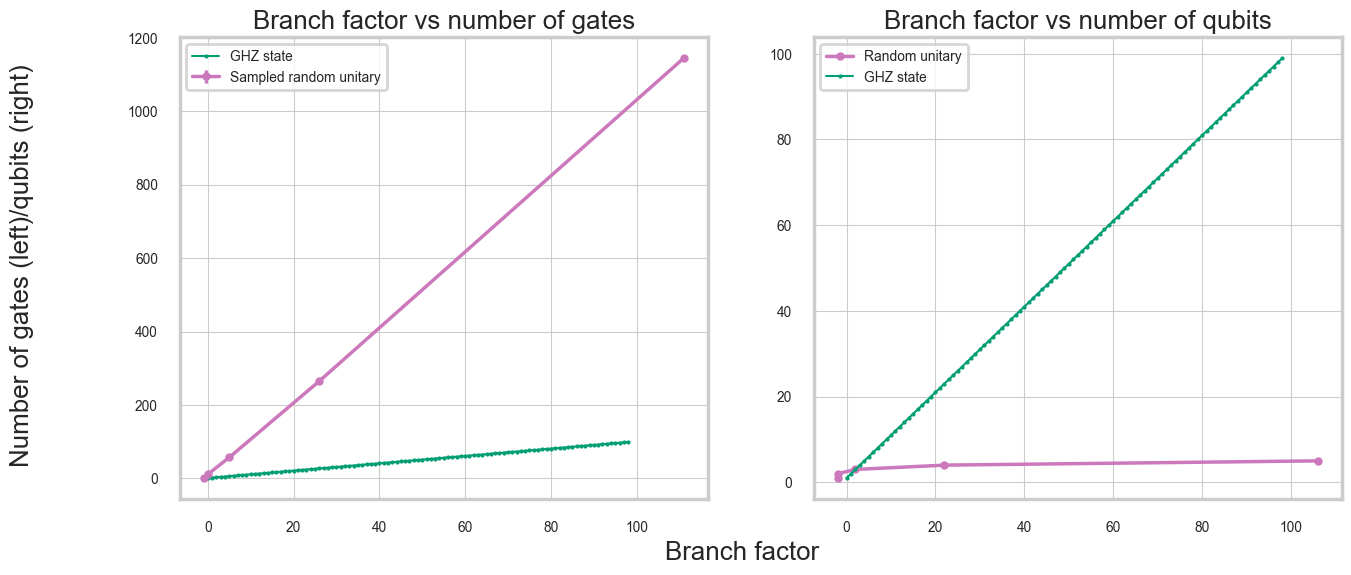

In [16]:
import seaborn as sns
min_friend = 1

random_unitary_friend_sizes = np.array(list(range(min_friend, 6)))
dicke_state_friend_sizes = np.array(list(range(min_friend, 12)))
ghz_state_friend_sizes = np.array(list(range(min_friend, 100)))

random_unitary_bf = np.array([4**n/9 - n/3 - 10/9 for n in random_unitary_friend_sizes])
dicke_state_bf = np.array([1*n**2 for n in dicke_state_friend_sizes])
ghz_state_bf = np.array([n - 1 for n in ghz_state_friend_sizes])

fig, axs = plt.subplots(1, 2, figsize=(15, 6))
palette = sns.color_palette("colorblind", n_colors=8)

marker="o"
marker_size = 5.0
linestyle = "-"
line_width = 2.5

axs[0].errorbar(random_unitary_bf, np.mean(random_unitaries_gates, axis=0), yerr=np.std(random_unitaries_gates, axis=0), label="Sampled random unitary", marker=marker, markersize=marker_size, color=palette[4], linestyle=linestyle, linewidth=line_width, elinewidth=line_width)
axs[0].set_title("Branch factor vs number of gates", fontsize="xx-large")
# axs[0].set_xticks(random_unitary_bf)

axs[0].grid(True)
# axs[0].plot(dicke_state_bf, dicke_states_gates, label="Dicke state", marker=marker, markersize=marker_size, color=palette[1], linestyle=linestyle, linewidth=line_width)
# axs[0].set_xticks(dicke_state_bf)

axs[0].plot(ghz_state_bf, ghz_states_gates, label="GHZ state", marker=marker, markersize=2, color=palette[2], linestyle=linestyle, linewidth=1.5)
# axs.set_xticks(ghz_state_bf)

theoretical_max_handle = mlines.Line2D([], [], color="tab:green", linestyle="dashed", linewidth=3, label="Theoretical maximum")
no_violation_handle = mlines.Line2D([], [], color="tab:red", linestyle="dotted", linewidth=3, label="No violation")

# fig.legend([theoretical_max_handle, no_violation_handle], ["Theoretical maximum", "No violation"], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05), fontsize="xx-large")



random_unitary_bf = np.array([4**n/9 - 4*n/3 - 10/9 for n in random_unitary_friend_sizes])
dicke_state_bf = np.array([1*n**2 for n in dicke_state_friend_sizes])
ghz_state_bf = np.array([n - 1 for n in ghz_state_friend_sizes])

axs[1].plot(random_unitary_bf, random_unitary_friend_sizes, label="Random unitary", marker=marker, markersize=marker_size, color=palette[4], linestyle=linestyle, linewidth=line_width)
# axs[0].plot(random_unitary_friend_sizes, 2**(2.15*random_unitary_friend_sizes), label="$2^{2.15\\cdot qubits}$", marker=marker, markersize=marker_size, color=palette[1], linestyle=linestyle, linewidth=line_width)

axs[1].set_title("Branch factor vs number of qubits", fontsize="xx-large")


# axs[1].plot(dicke_state_bf, dicke_state_friend_sizes, label="Dicke state", marker=marker, markersize=marker_size, color=palette[1], linestyle=linestyle, linewidth=line_width)

axs[1].plot(ghz_state_bf, ghz_state_friend_sizes, label="GHZ state", marker=marker, markersize=2, color=palette[2], linestyle=linestyle, linewidth=1.5)
axs[1].grid(True)
fig.text(0.5, 0.02, "Branch factor", ha="center", va="center", fontsize="xx-large")
fig.text(0.02, 0.5, "Number of gates (left)/qubits (right)", ha="center", va="center", rotation="vertical", fontsize="xx-large")

axs[0].legend()
axs[1].legend()
plt.savefig("branchfactor_vs_gatesqubits.pdf", bbox_inches='tight')
plt.show()

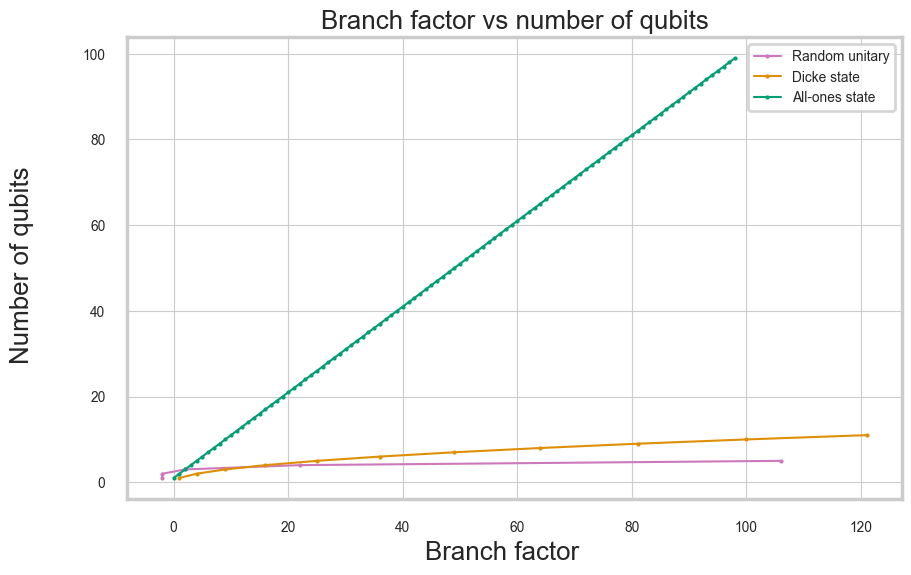

In [17]:
import seaborn as sns
min_friend = 1

random_unitary_friend_sizes = np.array(list(range(min_friend, 6)))
dicke_state_friend_sizes = np.array(list(range(min_friend, 12)))
ghz_state_friend_sizes = np.array(list(range(min_friend, 100)))

random_unitary_bf = np.array([4**n/9 - 4*n/3 - 10/9 for n in random_unitary_friend_sizes])
dicke_state_bf = np.array([1*n**2 for n in dicke_state_friend_sizes])
ghz_state_bf = np.array([n - 1 for n in ghz_state_friend_sizes])

fig, axs = plt.subplots(1, 1, figsize=(10, 6))
palette = sns.color_palette("colorblind", n_colors=8)

marker="o"
marker_size = 2.0
linestyle = "-"
line_width = 1.5

axs.plot(random_unitary_bf, random_unitary_friend_sizes, label="Random unitary", marker=marker, markersize=marker_size, color=palette[4], linestyle=linestyle, linewidth=line_width)
# axs[0].plot(random_unitary_friend_sizes, 2**(2.15*random_unitary_friend_sizes), label="$2^{2.15\\cdot qubits}$", marker=marker, markersize=marker_size, color=palette[1], linestyle=linestyle, linewidth=line_width)

# axs[0].axhline(0.380364, color="tab:green", linestyle="dashed", label="_nolegend_", linewidth=line_width)
# axs[0].axhline(0, color="tab:red", linestyle="dotted", label="_nolegend_", linewidth=line_width)
axs.set_title("Branch factor vs number of qubits", fontsize="xx-large")
# axs[0].set_xticks(random_unitary_bf)

axs.plot(dicke_state_bf, dicke_state_friend_sizes, label="Dicke state", marker=marker, markersize=marker_size, color=palette[1], linestyle=linestyle, linewidth=line_width)
# axs[1].plot(dicke_state_friend_sizes, 13*dicke_state_friend_sizes**2, label="$13\cdot qubits^2$", marker=marker, markersize=marker_size, color=palette[4], linestyle=linestyle, linewidth=line_width)

# axs[1].axhline(0.380364, color="tab:green", linestyle="dashed", label="_nolegend_", linewidth=line_width)
# axs[1].axhline(0, color="tab:red", linestyle="dotted", label="_nolegend_", linewidth=line_width)
# axs[1].set_title("Dicke state", fontsize="xx-large")
# axs[0].set_xticks(dicke_state_bf)

axs.plot(ghz_state_bf, ghz_state_friend_sizes, label="All-ones state", marker=marker, markersize=marker_size, color=palette[2], linestyle=linestyle, linewidth=line_width)
# axs[2].plot(ghz_state_friend_sizes, ghz_state_friend_sizes, label="$13\cdot qubits^2$", marker=marker, markersize=marker_size, color=palette[4], linestyle=linestyle, linewidth=line_width)

# axs[1].axhline(0.380364, color="tab:green", linestyle="dashed", label="_nolegend_", linewidth=line_width)
# axs[1].axhline(0, color="tab:red", linestyle="dotted", label="_nolegend_", linewidth=line_width)
# axs[2].set_title("All-ones state", fontsize="xx-large")
# axs.set_xticks(ghz_state_bf)

theoretical_max_handle = mlines.Line2D([], [], color="tab:green", linestyle="dashed", linewidth=3, label="Theoretical maximum")
no_violation_handle = mlines.Line2D([], [], color="tab:red", linestyle="dotted", linewidth=3, label="No violation")

# fig.legend([theoretical_max_handle, no_violation_handle], ["Theoretical maximum", "No violation"], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05), fontsize="xx-large")

fig.text(0.5, 0.02, "Branch factor", ha="center", va="center", fontsize="xx-large")
fig.text(0.02, 0.5, "Number of qubits", ha="center", va="center", rotation="vertical", fontsize="xx-large")

axs.legend()
# axs[1].legend()
plt.savefig("branchfactor_vs_qubits.pdf", bbox_inches='tight')
plt.show()

In [18]:
# Read in controlled random unitary data.
random_unitary_friend_sizes = list(range(2, 6))
with open("random_unitary_res.pkl", "rb") as handle:
    random_unitary_ideal = pickle.load(handle)

with open("random_unitary_res_0_0005dep.pkl", "rb") as handle:
    random_unitary_depolarizing_005 = pickle.load(handle)

with open("random_unitary_res_0_001dep.pkl", "rb") as handle:
    random_unitary_depolarizing_01 = pickle.load(handle)

# with open("random_unitary_res_0_002dep.pkl", "rb") as handle:
#     random_unitary_depolarizing_02 = pickle.load(handle)

# Read in Dicke state data.
dicke_state_friend_sizes = list(range(1, 8))
with open("dicke_states_res_0_0005dep.pkl", "rb") as handle:
    dicke_states_depolarizing_005_data = pickle.load(handle)

dicke_states_depolarizing_005 = np.zeros((len(dicke_state_friend_sizes), num_trials))
for i,size in enumerate(dicke_state_friend_sizes):
    dicke_states_depolarizing_005[i] = np.array(dicke_states_depolarizing_005_data[i+1]['semi_brukner'])

with open("dicke_states_res_0_001dep.pkl", "rb") as handle:
    dicke_states_depolarizing_01_data = pickle.load(handle)

dicke_states_depolarizing_01 = np.zeros((len(dicke_state_friend_sizes), num_trials))
for i,size in enumerate(dicke_state_friend_sizes):
    dicke_states_depolarizing_01[i] = np.array(dicke_states_depolarizing_01_data[i+1]['semi_brukner'])

with open("dicke_states_res_0_002dep.pkl", "rb") as handle:
    dicke_states_depolarizing_02_data = pickle.load(handle)

dicke_states_depolarizing_02 = np.zeros((len(dicke_state_friend_sizes), num_trials))
for i,size in enumerate(dicke_state_friend_sizes):
    dicke_states_depolarizing_02[i] = np.array(dicke_states_depolarizing_02_data[i+1]['semi_brukner'])
# with open("dicke_states_res.pkl", "rb") as handle:
#     dicke_states_ideal = pickle.load(handle)

fig, axs = plt.subplots(1, 2, figsize=(15, 6))
palette = sns.color_palette("colorblind", n_colors=8)

marker="o"
marker_size = 10
linestyle = "-"
line_width = 2.5

axs[0].plot(random_unitary_friend_sizes, np.mean(random_unitary_ideal, axis=0), label="Ideal simulator", marker=marker, markersize=marker_size, color=palette[0], linestyle=linestyle, linewidth=line_width)
axs[0].errorbar(random_unitary_friend_sizes, np.mean(random_unitary_ideal, axis=0), yerr=np.std(random_unitary_ideal, axis=0), fmt="none", capsize=5, color=palette[0], elinewidth=line_width)

axs[0].plot(random_unitary_friend_sizes, np.mean(random_unitary_depolarizing_005, axis=0), label="0.005% depolarizing noise", marker=marker, markersize=marker_size, color=palette[1], linestyle=linestyle, linewidth=line_width)
axs[0].errorbar(random_unitary_friend_sizes, np.mean(random_unitary_depolarizing_005, axis=0), yerr=np.std(random_unitary_depolarizing_005, axis=0), fmt="none", color=palette[1], capsize=5, elinewidth=line_width)

axs[0].plot(random_unitary_friend_sizes, np.mean(random_unitary_depolarizing_01, axis=0), label="0.01% depolarizing noise", marker=marker, markersize=marker_size, color=palette[4], linestyle=linestyle, linewidth=line_width)
axs[0].errorbar(random_unitary_friend_sizes, np.mean(random_unitary_depolarizing_01, axis=0), yerr=np.std(random_unitary_depolarizing_01, axis=0), fmt="none", capsize=5, color=palette[4], elinewidth=line_width)

# axs[0].plot(random_unitary_friend_sizes, np.mean(random_unitary_depolarizing_02, axis=0), label="0.02% depolarizing noise", marker=marker, markersize=marker_size, color=palette[7], linestyle=linestyle, linewidth=line_width)
# axs[0].errorbar(random_unitary_friend_sizes, np.mean(random_unitary_depolarizing_02, axis=0), yerr=np.std(random_unitary_depolarizing_02, axis=0), fmt="none", capsize=5, color=palette[7], elinewidth=line_width)

axs[0].axhline(0.828, color="tab:green", linestyle="dashed", label="_nolegend_", linewidth=line_width)
axs[0].axhline(0, color="tab:red", linestyle="dotted", label="_nolegend_", linewidth=line_width)
axs[0].set_title("Controlled random unitary", fontsize="xx-large")
axs[0].set_xticks(random_unitary_friend_sizes)

# axs[1].plot(dicke_state_friend_sizes, dicke_states_ideal, label="Ideal simulator", marker=marker, markersize=marker_size, color=palette[0], linestyle=linestyle, linewidth=line_width)
axs[1].errorbar(dicke_state_friend_sizes, np.mean(dicke_states_depolarizing_005, axis=1), yerr=np.std(dicke_states_depolarizing_005, axis=1), label="0.005% depolarizing noise", marker=marker, markersize=marker_size, color=palette[1], linestyle=linestyle, linewidth=line_width)
axs[1].errorbar(dicke_state_friend_sizes, np.mean(dicke_states_depolarizing_01, axis=1), yerr=np.std(dicke_states_depolarizing_01, axis=1), label="0.01% depolarizing noise", marker=marker, markersize=marker_size, color=palette[4], linestyle=linestyle, linewidth=line_width)
axs[1].errorbar(dicke_state_friend_sizes, np.mean(dicke_states_depolarizing_02, axis=1), yerr=np.std(dicke_states_depolarizing_02, axis=1), label="0.02% depolarizing noise", marker=marker, markersize=marker_size, color=palette[7], linestyle=linestyle, linewidth=line_width)

axs[1].axhline(0.828, color="tab:green", linestyle="dashed", label="_nolegend_", linewidth=line_width)
axs[1].axhline(0, color="tab:red", linestyle="dotted", label="_nolegend_", linewidth=line_width)
axs[1].set_title("Dicke states", fontsize="xx-large")
axs[1].set_xticks(dicke_state_friend_sizes)

theoretical_max_handle = mlines.Line2D([], [], color="tab:green", linestyle="dashed", linewidth=3, label="Theoretical maximum")
no_violation_handle = mlines.Line2D([], [], color="tab:red", linestyle="dotted", linewidth=3, label="No violation")

fig.legend([theoretical_max_handle, no_violation_handle], ["Theoretical maximum", "No violation"], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05), fontsize="xx-large")

fig.text(0.5, 0.02, "Charlie Size (Number of qubits)", ha="center", va="center", fontsize="xx-large")
fig.text(0.02, 0.5, "Semi-Brukner Violation Value", ha="center", va="center", rotation="vertical", fontsize="xx-large")

axs[0].legend()
axs[1].legend()
plt.savefig("controlled_random_unitary_vs_dicke_state.pdf", bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'random_unitary_res_0_0005dep.pkl'

In [ ]:
dicke_states_depolarizing_005_data[1]